This work develops a Gaussian Process Approximation (GPA) model to address the computational challenges of standard Gaussian Processes when the input size increases. The approach employs Random Fourier Features (RFF) to approximate the kernel function and reduce the matrix dimensionality, thereby improving computational efficiency. Using this simplified representation, the model optimizes the lengthscale, coefficient, and noise parameters via the SciPy optimizer. Based on the optimized values, the mean and standard deviation of the predictions are computed for the training, validation, and test datasets. Additionally, the model’s performance is evaluated using statistical metrics such as R², MSE, NLL, and miscalibration area.

GPA

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from datetime import datetime
import os

# ---------------- Load data ----------------
data = pd.read_csv("/Users/monibor/Desktop/polarized_proton_data_with_current.csv") 

# Include multiple SampleIDs
filtered_data = data[data["SampleID"].isin(["(P07)", "(P14)", "(P11)"])].reset_index(drop=True)

feature_cols = ["scaler_calc1", "uwave_freq", "TGT:PT12:Target_Dose"]
X = filtered_data[feature_cols].values
y = filtered_data["polarization"].values.reshape(-1, 1)

# ---------------- Train/Validation/Test Split ----------------
# Balanced representation of the target variable (y) distribution across train, validation, and test splits.
y_quantiles = pd.qcut(y.ravel(), q=10, labels=False)

X_trainval, X_test, y_trainval, y_test, idx_trainval, idx_test = train_test_split(
    X, y, filtered_data.index.values, test_size=0.1, random_state=42, stratify=y_quantiles
)

y_trainval_quantiles = pd.qcut(y_trainval.ravel(), q=10, labels=False)
X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X_trainval, y_trainval, idx_trainval, test_size=0.1111, random_state=42, stratify=y_trainval_quantiles
)  

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# ---------------- Standardize (fit on training only) ----------------
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train).ravel()
y_val_scaled = scaler_y.transform(y_val).ravel()
y_test_scaled = scaler_y.transform(y_test).ravel()

# ---------------- GPA-RFF Model ----------------
class GPA_RFF:
    def __init__(self, X, y, kernel="RBF", D=500, seed=42):
        self.X = X.astype(np.float64)
        self.y = y.astype(np.float64)
        self.kernel = kernel.upper()
        self.D = D
        np.random.seed(seed)

        self.b = 2 * np.pi * np.random.rand(D)
        self.W = None
        self.beta = None
        self.opt_params = None

        self.log_lengthscale = np.log(1.0)
        self.log_coeff = np.log(1.0)
        self.log_noise = np.log(1e-2)

    def _sample_W(self, lengthscale):
        d = self.X.shape[1]
        if self.kernel in ["RBF", "EQ"]:
            return np.random.normal(0, 1.0 / lengthscale, (d, self.D))
        elif self.kernel == "LAPLACE":
            return np.random.standard_cauchy((d, self.D)) / lengthscale
        elif self.kernel == "CAUCHY":
            return np.random.laplace(0, 1.0 / lengthscale, (d, self.D))
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")

    def _phi(self, X, W, coeff):
        return np.sqrt(2/self.D) * np.cos(X @ W + self.b) * np.sqrt(coeff) # RFF transformation

    def neg_log_likelihood(self, params):
        lengthscale, coeff, noise = np.exp(params)
        lengthscale = np.clip(lengthscale, 1e-2, 1e5)
        coeff = np.clip(coeff, 1e-6, 1e5)
        noise = np.clip(noise, 1e-3, 10.0)

        if self.W is None:
            self.W = self._sample_W(lengthscale)

        phi = self._phi(self.X, self.W, coeff)
        K_ridge = phi.T @ phi + (noise**2) * np.eye(self.D)
        try:
            beta = np.linalg.solve(K_ridge, phi.T @ self.y)
            y_pred = phi @ beta
            nll = 0.5*np.sum((self.y - y_pred)**2)/(noise**2) + 0.5*self.X.shape[0]*np.log(2*np.pi*noise**2)
        except np.linalg.LinAlgError:
            nll = 1e10
        return nll

    def fit(self, method="L-BFGS-B"):
        init = [self.log_lengthscale, self.log_coeff, self.log_noise]
        # Initial boundary
        bounds = [
            (np.log(1e-2), np.log(1e5)),
            (np.log(1e-6), np.log(1e5)),
            (np.log(1e-3), np.log(10.0)),
        ]
        res = minimize(self.neg_log_likelihood, init, method=method, bounds=bounds) # Scipy minimizer
        self.opt_params = np.exp(res.x)

        lengthscale, coeff, noise = self.opt_params
        self.W = self._sample_W(lengthscale)
        phi = self._phi(self.X, self.W, coeff)
        K_ridge = phi.T @ phi + (noise**2) * np.eye(self.D)
        self.beta = np.linalg.solve(K_ridge, phi.T @ self.y)
        return res

    def predict(self, X_new, return_std=True):
        lengthscale, coeff, noise = self.opt_params
        phi_new = self._phi(X_new, self.W, coeff)
        y_pred = phi_new @ self.beta # Mean
        y_pred = y_pred.ravel() 
        phi_train = self._phi(self.X, self.W, coeff)
        K_ridge = phi_train.T @ phi_train + (noise**2) * np.eye(self.D)
        v = np.linalg.solve(K_ridge, phi_new.T)
        y_var = noise**2 + np.sum(phi_new * v.T, axis=1)
        y_std = np.sqrt(np.maximum(y_var, 1e-12)) # standard deviation
        return y_pred, y_std.ravel()


# ---------------- Run experiments ----------------
os.makedirs("results", exist_ok=True)
summary_path = "results/gpa_rff_summary.csv"

# Initialize metrics summary file
summary_cols = ["Kernel", "Optimizer", "Dataset", "MSE", "R2", "NLL", "Miscal_Area"]
if not os.path.exists(summary_path):
    pd.DataFrame(columns=summary_cols).to_csv(summary_path, index=False)

kernels = ["RBF", "LAPLACE", "CAUCHY"]
methods = ["Nelder-Mead", "L-BFGS-B"]

for kernel in kernels:
    print("="*70)
    print(f"Kernel: {kernel}")
    for method in methods:
        print(f"\nOptimizer: {method}")

        gp = GPA_RFF(X_train_scaled, y_train_scaled, kernel=kernel, D=2000)
        try:
            res = gp.fit(method=method)
            print(f"Optimized params [lengthscale, coeff, noise]: {gp.opt_params}")

            coverage_levels = np.linspace(0, 1, 100)
            # predict for all data separately (train, val and test)

            datasets = [
                ("train", X_train_scaled, y_train, idx_train),
                ("val", X_val_scaled, y_val, idx_val),
                ("test", X_test_scaled, y_test, idx_test)
            ]

            for name, Xs, Ys, idxs in datasets:
                # Predict
                y_pred, y_std = gp.predict(Xs)
                y_orig = Ys.ravel()
                # Back to original labels
                y_pred_orig = scaler_y.inverse_transform(y_pred.reshape(-1,1)).ravel()
                y_std_orig = y_std * scaler_y.scale_[0]

                # Reconstruct original features 
                df_features = pd.DataFrame(
                    scaler_X.inverse_transform(Xs), 
                    columns=feature_cols
                )
                df_features["start_time"] = filtered_data.loc[idxs, "start_time"].values
                df_features["end_time"] = filtered_data.loc[idxs, "end_time"].values

                df = pd.DataFrame({
                    "SampleID": filtered_data.loc[idxs, "SampleID"].values,
                    **df_features,
                    "y_true": y_orig,
                    "y_pred": y_pred_orig,
                    "y_std": y_std_orig
                })

                # Save predictions CSV
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                filename = f"results/gpa_rff_{kernel}_{method}_{name}_{timestamp}.csv"
                df.to_csv(filename, index=False)

                # ---- Metrics ----
                mse = mean_squared_error(y_orig, y_pred_orig)
                r2 = r2_score(y_orig, y_pred_orig)
                nll = 0.5*np.sum((y_orig - y_pred_orig)**2)/(gp.opt_params[2]**2) + 0.5*len(y_orig)*np.log(2*np.pi*gp.opt_params[2]**2)
                observed = [(np.abs(y_orig - y_pred_orig) <= q*y_std_orig).mean() for q in coverage_levels]
                miscal_area = np.trapezoid(np.abs(coverage_levels - np.array(observed)), coverage_levels)

                print(f"{name.capitalize()} MSE: {mse:.5f}, R²: {r2:.5f}, NLL: {nll:.5f}, Miscal Area: {miscal_area:.5f}")

                # ---- Save metrics to summary CSV ----
                new_row = pd.DataFrame([[kernel, method, name, mse, r2, nll, miscal_area]], columns=summary_cols)
                new_row.to_csv(summary_path, mode='a', header=False, index=False)

        except Exception as e:
            print(f" Error with {kernel} + {method}: {e}")


Train: 4493, Val: 562, Test: 562
Kernel: RBF

Optimizer: Nelder-Mead
Optimized params [lengthscale, coeff, noise]: [1.0000000e-02 1.0000000e+05 1.0704555e-01]
Train MSE: 0.00144, R²: 0.71132, NLL: -5629.48243, Miscal Area: 0.04976
Val MSE: 0.00900, R²: -0.85678, NLL: -518.55147, Miscal Area: 0.13077
Test MSE: 0.00726, R²: -0.49698, NLL: -561.22602, Miscal Area: 0.10398

Optimizer: L-BFGS-B
Optimized params [lengthscale, coeff, noise]: [1.0000000e+00 1.0000000e+05 1.0704755e-01]
Train MSE: 0.00006, R²: 0.98750, NLL: -5898.55409, Miscal Area: 0.28818
Val MSE: 0.00025, R²: 0.94772, NLL: -733.11949, Miscal Area: 0.28572
Test MSE: 0.00067, R²: 0.86225, NLL: -722.94594, Miscal Area: 0.27804
Kernel: LAPLACE

Optimizer: Nelder-Mead
Optimized params [lengthscale, coeff, noise]: [1.00056401 1.00126161 0.07039592]
Train MSE: 0.00003, R²: 0.99464, NLL: -7781.83958, Miscal Area: 0.40499
Val MSE: 0.00006, R²: 0.98739, NLL: -971.42275, Miscal Area: 0.40481
Test MSE: 0.00002, R²: 0.99492, NLL: -973.49

Analysis of the performance of the test output (Laplace + Nelder-Mead) 

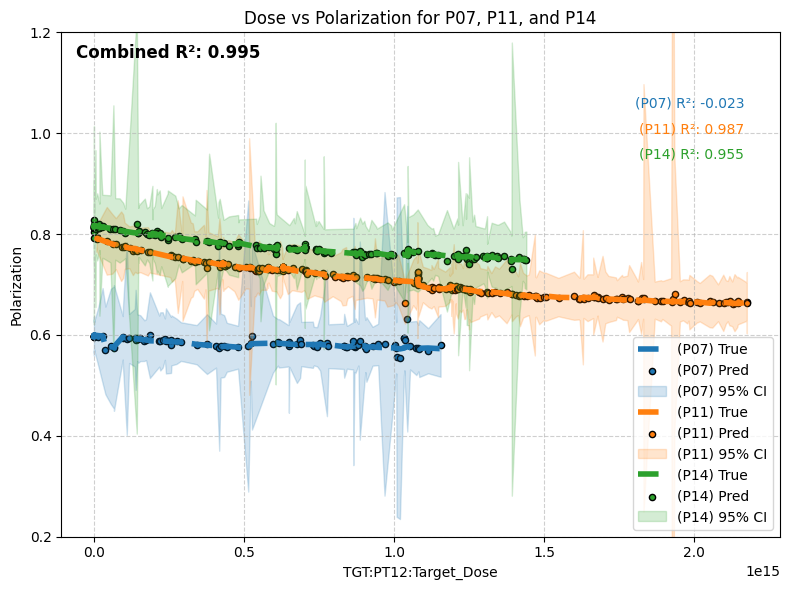

In [5]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

Test_results = pd.read_csv("/Users/monibor/Desktop/AIOP Target Optimization/untitled folder/GP/Generalized model/results/gpa_rff_LAPLACE_Nelder-Mead_test_20251031_111056.csv")
Test_results["start_time"] = pd.to_datetime(Test_results["start_time"], errors="coerce")

# Separate and sort by SampleID
sample_dfs = {}
for sample_id, df_sample in Test_results.groupby("SampleID"):
    df_sorted = df_sample.sort_values(by="start_time").reset_index(drop=True)
    sample_dfs[sample_id] = df_sorted

# Choose samples and assign colors
samples_to_plot = ["(P07)", "(P11)", "(P14)"]
colors = ["tab:blue", "tab:orange", "tab:green"]

plt.figure(figsize=(8,6))

r2_values = {}

# Plot each sample
for sample_id, color in zip(samples_to_plot, colors):
    df = sample_dfs[sample_id].sort_values("TGT:PT12:Target_Dose")

    # Compute R²
    r2 = r2_score(df["y_true"], df["y_pred"])
    r2_values[sample_id] = r2

    # True values (thicker dashed line)
    plt.plot(df["TGT:PT12:Target_Dose"], df["y_true"], linestyle="--", linewidth=4, color=color, label=f"{sample_id} True")

    # Predicted values (markers)
    plt.scatter(df["TGT:PT12:Target_Dose"], df["y_pred"], color=color, edgecolor='k', s=20, marker="o", label=f"{sample_id} Pred")

    # 95% confidence interval
    plt.fill_between(
        df["TGT:PT12:Target_Dose"],
        df["y_pred"] - 1.96 * df["y_std"],
        df["y_pred"] + 1.96 * df["y_std"],
        color=color,
        alpha=0.2,
        label=f"{sample_id} 95% CI"
    )

# Combined R² for all three samples
combined_df = Test_results[Test_results["SampleID"].isin(samples_to_plot)]
combined_r2 = r2_score(combined_df["y_true"], combined_df["y_pred"])

plt.xlabel("TGT:PT12:Target_Dose")
plt.ylabel("Polarization")
plt.title("Dose vs Polarization for P07, P11, and P14")
plt.grid(True, linestyle="--", alpha=0.6)
plt.ylim(0.2, 1.2)
plt.legend(loc="lower right")

# Add R² values as text
for i, sample_id in enumerate(samples_to_plot):
    plt.text(0.95, 0.85 - i*0.05, f"{sample_id} R²: {r2_values[sample_id]:.3f}",
             transform=plt.gca().transAxes, ha='right', fontsize=10, color=colors[i])

# Combined R² in top-left corner
plt.text(0.02, 0.95, f"Combined R²: {combined_r2:.3f}", transform=plt.gca().transAxes,
         ha='left', fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.show()
